- import library

In [9]:
import os
import json
import pickle
import random
import math
 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [10]:
models = tf.keras.models
layers = tf.keras.layers
callbacks = tf.keras.callbacks
preprocessing = tf.keras.preprocessing

# Definisikan variabel yang tadi merah
EarlyStopping = callbacks.EarlyStopping
ReduceLROnPlateau = callbacks.ReduceLROnPlateau
ModelCheckpoint = callbacks.ModelCheckpoint
ImageDataGenerator = preprocessing.image.ImageDataGenerator

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [11]:
CONFIG = {
    # Data
    "data_dir":        "aksara_sunda",
    "img_size":        128,
    # Split
    "test_size":       0.15,
    "val_size":        0.15,
    "random_seed":     42,
    # Training
    "batch_size":      32,
    "epochs":          100,
    "learning_rate":   1e-4,
    # Files
    "model_path":      "aksara_model.keras",
    "encoder_path":    "label_encoder.pkl",
    "history_path":    "training_history.json",
    "checkpoint_path": "best_model.keras",
}


In [12]:
tf.random.set_seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])
random.seed(CONFIG["random_seed"])
 

- load dataset

In [13]:
def load_dataset(data_dir: str, img_size: int) -> tuple[np.ndarray, list[str]]:

    assert os.path.exists(data_dir), f"Data dir tidak ditemukan: {data_dir}"
 
    images, labels = [], []
    skipped = 0
 
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
 
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            img = cv2.imread(fpath)
 
            if img is None:
                print(f"[WARNING] Skip (tidak terbaca): {fpath}")
                skipped += 1
                continue
 
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(class_name)
 
    X = np.array(images, dtype="float32") / 255.0
    print(f"Loaded  : {len(images)} gambar | {len(set(labels))} kelas | skip={skipped}")
    print(f"Shape   : {X.shape}")
    return X, labels

In [14]:
def check_class_balance(labels: list[str]) -> None:
    """Tampilkan jumlah sampel per kelas."""
    unique, counts = np.unique(labels, return_counts=True)
    print("\nDistribusi kelas:")
    for cls, cnt in zip(unique, counts):
        print(f"  {cls:<6} : {cnt}")

In [15]:
def encode_and_split(
    X: np.ndarray,
    labels: list[str],
    test_size: float,
    val_size: float,
    seed: int,
) -> tuple:

    le = LabelEncoder()
    y = le.fit_transform(labels)
 
    temp_frac = test_size + val_size
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=temp_frac, stratify=y, random_state=seed
    )
    val_frac_of_temp = val_size / temp_frac
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=(1.0 - val_frac_of_temp),
        stratify=y_temp,
        random_state=seed,
    )
 
    print(f"\nSplit   : train={len(X_train)} | val={len(X_val)} | test={len(X_test)}")
    return X_train, X_val, X_test, y_train, y_val, y_test, le


In [16]:
def build_datagen() -> ImageDataGenerator: # type: ignore
    return ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        fill_mode="constant",
        cval=255.0
    )

- visualisasi

In [17]:
def build_model(num_classes: int, img_size: int) -> tf.keras.Model:
    # 1. Load pre-trained MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet" 
    )
    
    # 2. FINE-TUNING
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
        
    # 3. Rangkai Model
    model = tf.keras.Sequential([
        tf.keras.layers.Lambda(lambda x: (x * 2.0) - 1.0, input_shape=(img_size, img_size, 3)),
        
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ], name="mobilenetv2_finetuned")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

- label encoding

In [18]:
def build_callbacks(checkpoint_path: str) -> list:
    return [
        EarlyStopping(
            monitor="val_accuracy",
            patience=10,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_accuracy",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
        ),
    ]
 

- split data

In [19]:
def train(model, datagen, X_train, y_train, X_val, y_val) -> tf.keras.callbacks.History:
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=CONFIG["batch_size"]),
        steps_per_epoch=math.ceil(len(X_train) / CONFIG["batch_size"]),
        epochs=CONFIG["epochs"],
        validation_data=(X_val, y_val),
        callbacks=build_callbacks(CONFIG["checkpoint_path"]),
    )
    return history


In [20]:
def evaluate(model, X_test, y_test, le: LabelEncoder) -> None:
    """Cetak accuracy, classification report, dan confusion matrix."""
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Loss    : {loss:.4f}")
    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
 
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
 
    print("=== Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
 
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=le.classes_, yticklabels=le.classes_,
    )
    plt.title("Confusion Matrix — Test Set")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()
 
 

In [21]:

def plot_history(history: tf.keras.callbacks.History) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    ax1.plot(history.history["accuracy"],     label="Train")
    ax1.plot(history.history["val_accuracy"], label="Validation")
    ax1.set_title("Accuracy per Epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
 
    ax2.plot(history.history["loss"],     label="Train")
    ax2.plot(history.history["val_loss"], label="Validation")
    ax2.set_title("Loss per Epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
 
    plt.tight_layout()
    plt.show()
 

In [22]:
def save_artifacts(model, le: LabelEncoder, history) -> None:
    """Simpan model, encoder, dan history — semua yang dibutuhkan untuk inference."""
    model.save(CONFIG["model_path"])
    print(f"[SAVED] Model     → {CONFIG['model_path']}")
 
    with open(CONFIG["encoder_path"], "wb") as f:
        pickle.dump(le, f)
    print(f"[SAVED] Encoder   → {CONFIG['encoder_path']}")
 
    with open(CONFIG["history_path"], "w") as f:
        json.dump(
            {k: [float(v) for v in vals] for k, vals in history.history.items()}, f
        )
    print(f"[SAVED] History   → {CONFIG['history_path']}")
 

In [23]:
def load_artifacts(
    model_path: str = CONFIG["model_path"],
    encoder_path: str = CONFIG["encoder_path"],
):
    """Load model + encoder untuk inference. Panggil sekali saat startup API."""
    model = tf.keras.models.load_model(model_path)
    with open(encoder_path, "rb") as f:
        le = pickle.load(f)
    return model, le

In [24]:
def preprocess_image(img_input, img_size: int = CONFIG["img_size"]) -> np.ndarray:
    """
    Preprocessing konsisten antara training dan inference.
 
    img_input bisa berupa:
      - str  : path ke file gambar
      - bytes: raw bytes dari upload (cocok untuk FastAPI / Flask)
      - np.ndarray: array BGR (dari cv2) atau RGB (dari PIL/canvas)
                    — jika BGR, set is_bgr=True
    """
    if isinstance(img_input, str):
        img = cv2.imread(img_input)
        if img is None:
            raise ValueError(f"Gambar tidak terbaca: {img_input}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
 
    elif isinstance(img_input, bytes):
        arr = np.frombuffer(img_input, dtype=np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        if img is None:
            raise ValueError("Gagal decode bytes menjadi gambar")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
 
    elif isinstance(img_input, np.ndarray):
        img = img_input.copy()
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
 
    else:
        raise TypeError(f"Tipe img_input tidak didukung: {type(img_input)}")
 
    img = cv2.resize(img, (img_size, img_size))
    return img.astype("float32") / 255.0

In [25]:
def predict(
    img_input,
    model,
    le: LabelEncoder,
    img_size: int = CONFIG["img_size"],
    top_k: int = 3,
) -> dict:
    """
    Prediksi satu gambar aksara Sunda.
 
    Returns:
        {
            "label":      "ka",
            "confidence": 0.98,
            "top_k": [
                {"label": "ka", "confidence": 0.98},
                {"label": "ga", "confidence": 0.01},
                {"label": "sa", "confidence": 0.005},
            ]
        }
    """
    img = preprocess_image(img_input, img_size)
    img_batch = np.expand_dims(img, axis=0)
 
    probs = model.predict(img_batch, verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:top_k]
 
    return {
        "label":      le.inverse_transform([top_indices[0]])[0],
        "confidence": float(probs[top_indices[0]]),
        "top_k": [
            {
                "label":      le.inverse_transform([i])[0],
                "confidence": float(probs[i]),
            }
            for i in top_indices
        ],
    }

In [26]:
def visualize_samples(X: np.ndarray, labels: list[str]) -> None:
    unique_labels = sorted(set(labels))
    cols = 5
    rows = math.ceil(len(unique_labels) / cols)
 
    plt.figure(figsize=(12, rows * 2.5))
    for i, label in enumerate(unique_labels):
        idx = labels.index(label)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(X[idx])
        plt.title(label, fontsize=9)
        plt.axis("off")
    plt.suptitle("Sampel per Kelas Aksara Sunda", fontsize=13)
    plt.tight_layout()
    plt.show()
 

In [27]:
def visualize_prediction(X_test, y_test, model, le, n: int = 5) -> None:
    """Tampilkan n gambar dari test set beserta prediksi & confidence."""
    indices = random.sample(range(len(X_test)), n)
    plt.figure(figsize=(3 * n, 4))
 
    for pos, idx in enumerate(indices):
        result = predict(X_test[idx], model, le)
        actual = le.inverse_transform([y_test[idx]])[0]
        color = "green" if result["label"] == actual else "red"
 
        plt.subplot(1, n, pos + 1)
        plt.imshow(X_test[idx])
        plt.title(
            f"Pred: {result['label']}\n"
            f"Conf: {result['confidence']:.2f}\n"
            f"True: {actual}",
            color=color, fontsize=9,
        )
        plt.axis("off")
 
    plt.suptitle("Prediksi pada Test Set (hijau=benar, merah=salah)")
    plt.tight_layout()
    plt.show()

Loaded  : 1800 gambar | 30 kelas | skip=0
Shape   : (1800, 128, 128, 3)

Distribusi kelas:
  a      : 60
  ae     : 60
  ba     : 60
  ca     : 60
  da     : 60
  e      : 60
  eu     : 60
  fa     : 60
  ga     : 60
  ha     : 60
  i      : 60
  ja     : 60
  ka     : 60
  la     : 60
  ma     : 60
  na     : 60
  nga    : 60
  nya    : 60
  o      : 60
  pa     : 60
  qa     : 60
  ra     : 60
  sa     : 60
  ta     : 60
  u      : 60
  va     : 60
  wa     : 60
  xa     : 60
  ya     : 60
  za     : 60


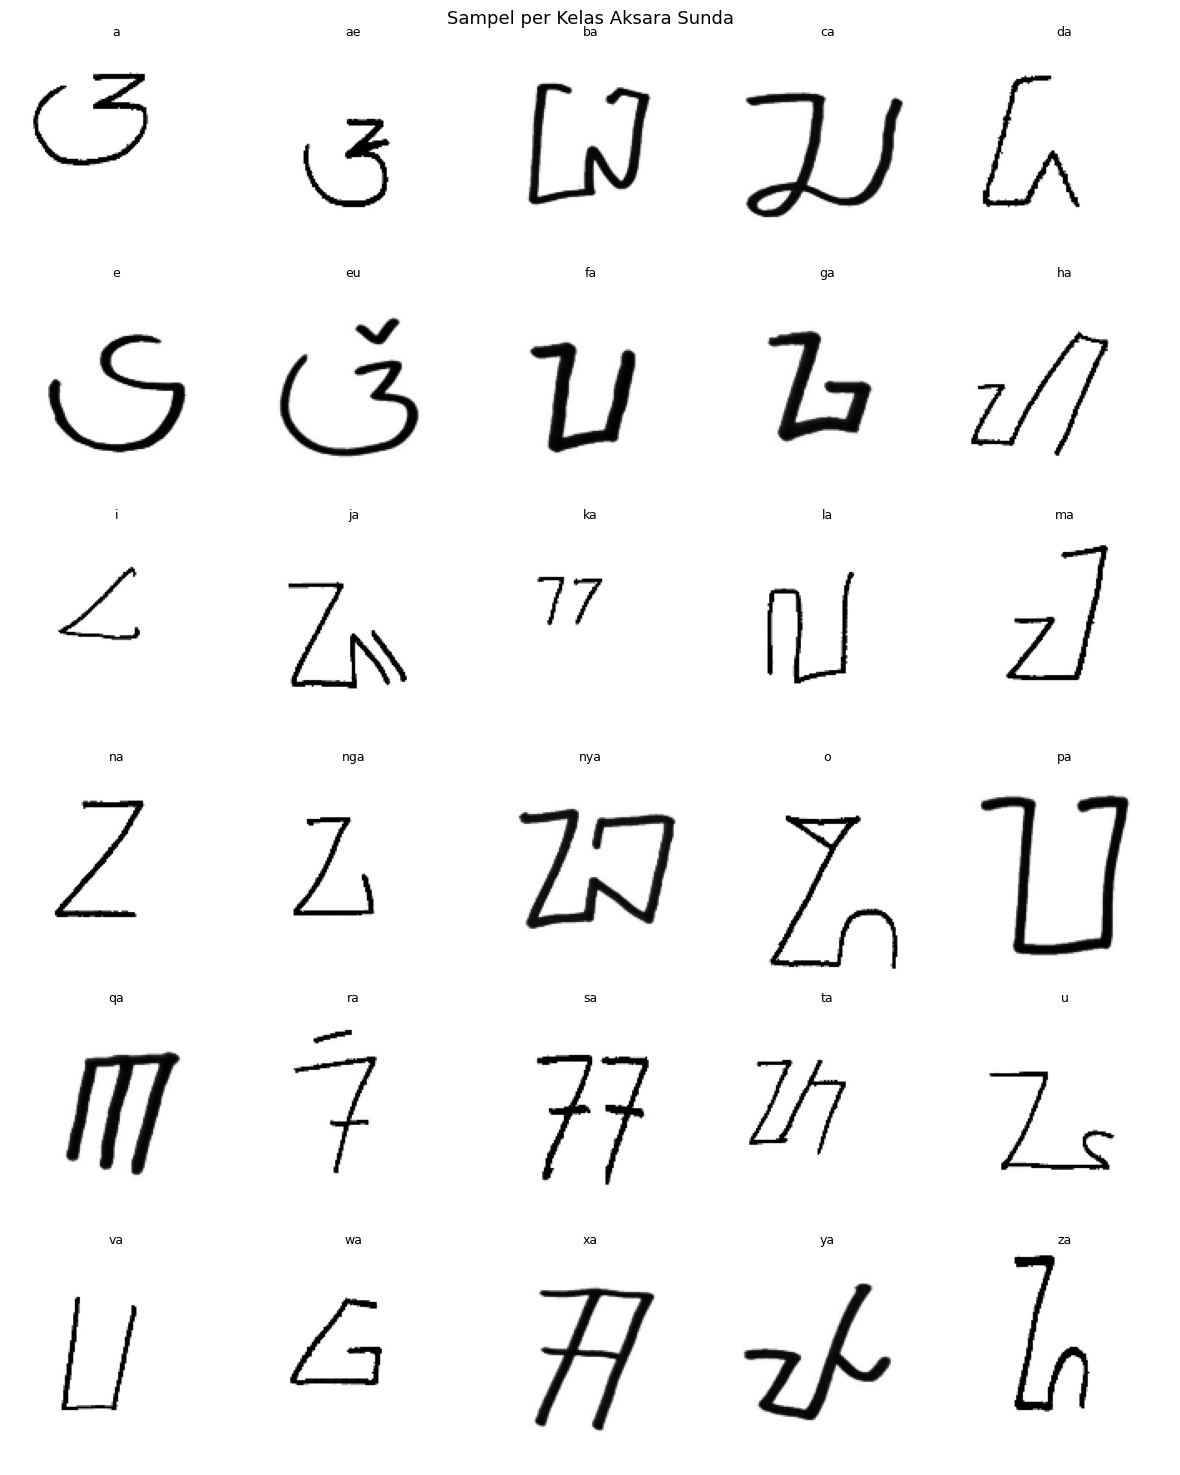


Split   : train=1260 | val=270 | test=270


/opt/anaconda3/envs/aksara/lib/python3.10/site-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "mobilenetv2_finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │        38,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,296,414 (8.76 MB)

 Trainable params: 1,564,830 (5.97 MB)

 Non-trainable params: 731,584 (2.79 MB)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.0704 - loss: 3.6776
Epoch 1: val_accuracy improved from None to 0.16296, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 250ms/step - accuracy: 0.1325 - loss: 3.2901 - val_accuracy: 0.1630 - val_loss: 2.8000 - learning_rate: 1.0000e-04
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.3765 - loss: 2.1361
Epoch 2: val_accuracy improved from 0.16296 to 0.32222, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 219ms/step - accuracy: 0.4452 - loss: 1.9291 - val_accuracy: 0.3222 - val_loss: 2.0768 - learning_rate: 1.0000e-04
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6170 - loss: 1.3297
Epoch 3: val_accuracy improved from 0.32222 to 0.42593, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 220ms/step - accuracy: 0.6421 - loss: 1.2308 - val_accuracy: 0.4259 - val_loss: 1.7907 - learning_rate: 1.0000e-04
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 

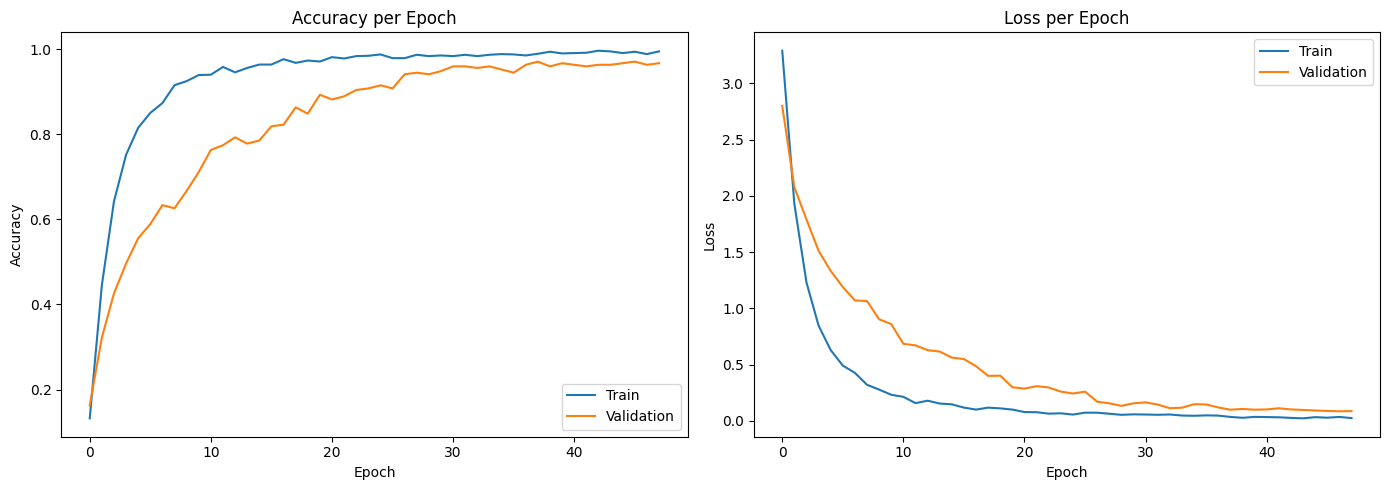


Test Loss    : 0.1349
Test Accuracy: 0.9630 (96.30%)

=== Classification Report ===
              precision    recall  f1-score   support

           a       0.82      1.00      0.90         9
          ae       0.88      0.78      0.82         9
          ba       0.89      0.89      0.89         9
          ca       1.00      1.00      1.00         9
          da       1.00      1.00      1.00         9
           e       1.00      1.00      1.00         9
          eu       1.00      0.89      0.94         9
          fa       0.90      1.00      0.95         9
          ga       1.00      1.00      1.00         9
          ha       1.00      1.00      1.00         9
           i       1.00      1.00      1.00         9
          ja       1.00      1.00      1.00         9
          ka       1.00      1.00      1.00         9
          la       1.00      1.00      1.00         9
          ma       1.00      1.00      1.00         9
          na       1.00      1.00      1.00       

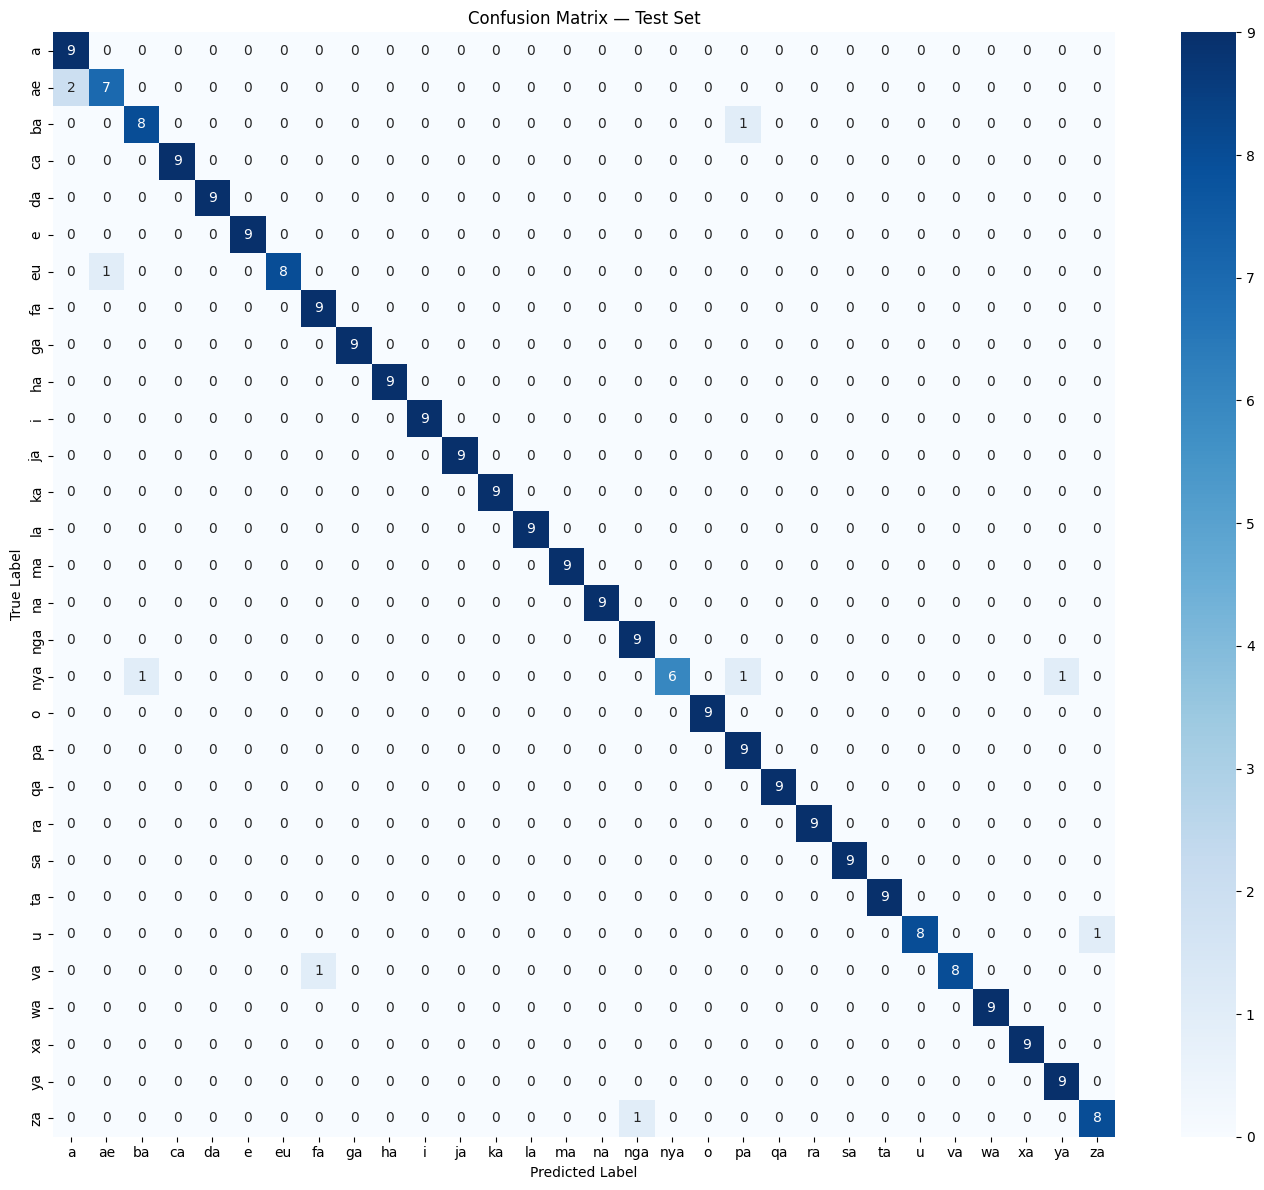

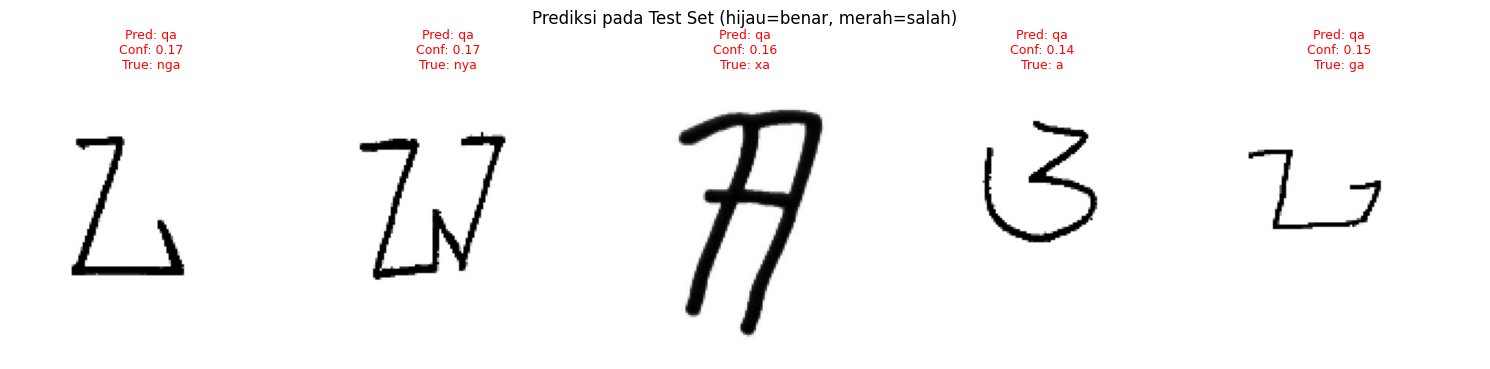

[SAVED] Model     → aksara_model.keras
[SAVED] Encoder   → label_encoder.pkl
[SAVED] History   → training_history.json


In [28]:
from re import A
if __name__ == "__main__":
 
    # Load & EDA
    X, labels = load_dataset(CONFIG["data_dir"], CONFIG["img_size"])
    check_class_balance(labels)
    visualize_samples(X, labels)
 
    # Encode & Split
    X_train, X_val, X_test, y_train, y_val, y_test, le = encode_and_split(
        X, labels,
        test_size=CONFIG["test_size"],
        val_size=CONFIG["val_size"],
        seed=CONFIG["random_seed"],
    )
 
    # Augmentation
    datagen = build_datagen()
 
    # Build & Train
    model = build_model(num_classes=len(le.classes_), img_size=CONFIG["img_size"])
    model.summary()
 
    history = train(model, datagen, X_train, y_train, X_val, y_val)
 
    # Evaluate
    plot_history(history)
    evaluate(model, X_test, y_test, le)
 
    # Visualize predictions
    visualize_prediction(X_test, y_test, model, le, n=5)
 
    # Save
    save_artifacts(model, le, history)